## Data preparation

In [1]:
%cd /home/maia-user/NeuroCBIR/
!ls

/home/maia-user/NeuroCBIR
cbir	    global_AE_training.ipynb  preprocessing	     training
CBIR.ipynb  main.ipynb		      README.md		     utils
data	    model		      seg_preparation.ipynb


/usr/local/lib/python3.10/dist-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
# import torch
# from model.autoencoder import Conv3DSparseAutoencoder
# from torchsummary import summary

# # Device setup
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # Input size: [160, 176, 208]
# input_size = [64, 80, 48]

# # Initialize model and move it to the correct device
# autoencoder = Conv3DSparseAutoencoder().to(device)

# # Run summary — torchsummary will match the device of the model
# _=summary(autoencoder, (1, *input_size))

In [3]:
import sys
print(sys.executable)


/usr/bin/python3


In [4]:
import torch
import torch.nn as nn
import os
import pandas as pd
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from IPython.display import clear_output

seed = 42

In [5]:
from preprocessing.load_dataset import list_files_with_extension, BrainMRIDataset, get_label

# Loading MRI  paths
dataset_path = r"/home/maia-user/Dataset/OASIS3_NPY_UINT/"
file_paths, file_names = list_files_with_extension(dataset_path, extension=".npy")
raw_image_paths = np.array([os.path.join(dataset_path, file_path, file_name) for file_path, file_name in zip(file_paths, file_names)])
raw_image_ids = np.array([file_path.split('.')[0] for file_path in file_names])

# Load file with labels
labels_path = r"/home/maia-user/Dataset/OASIS3/OASIS3_UDSb4_cdr.xlsx"
labels_df = pd.read_excel(labels_path, sheet_name= 'Labels')

# Some recordings might be removed, i.e. nan labels
raw_labels = np.array([get_label(image_id, labels_df) for image_id in raw_image_ids]).astype('float32')
raw_ages = np.array([get_label(image_id, labels_df, column='age_at_visit') for image_id in raw_image_ids]).astype('float32')
raw_ids = np.array([get_label(image_id, labels_df, column='OASISID') for image_id in raw_image_ids])

# Filtering out undesired cases
labels = raw_labels[~np.isnan(raw_labels)]
image_paths = raw_image_paths[~np.isnan(raw_labels)]
ages = raw_ages[~np.isnan(raw_labels)]
ids = raw_ids[~np.isnan(raw_labels)]

print(raw_labels.shape, labels.shape)

/home/maia-user/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(2681,) (2680,)


In [6]:
from preprocessing.split_dataset import stratified_patient_split

# Longitudinal splitting dataset into training and testing sets
train_set, val_set, test_set = stratified_patient_split(image_paths, labels, ages, ids)

# Print dataset sizes
print(f"Training samples: {len(train_set['image_paths'])} - IR: {np.sum(train_set['labels'])/len(train_set['image_paths']):.2f}")
print(f"Validation samples: {len(val_set['image_paths'])} - IR: {np.sum(val_set['labels'])/len(val_set['image_paths']):.2f}")
print(f"Testing samples: {len(test_set['image_paths'])} - IR: {np.sum(test_set['labels'])/len(val_set['image_paths']):.2f}")

Training samples: 1852 - IR: 0.20
Validation samples: 372 - IR: 0.21
Testing samples: 456 - IR: 0.26


In [7]:
from preprocessing.load_dataset import StratifiedBatchSampler
import torchio as tio

batch_size = 24  # Make sure this is even!

augmentation_transforms = tio.Compose([
                                        # tio.RandomAffine(
                                        #     scales=(0.9, 1.05),        # Random scaling
                                        #     degrees=5,               # Random rotation in degrees
                                        #     translation=5            # Random translation in mm
                                        # ),
                                        tio.RandomNoise(mean=0.0, std=0.02),
                                        # tio.RandomFlip(axes=('LR',)),  # Random left-right flip
                                    ])

# Preparing the dataset to feed the network
train_dataset = BrainMRIDataset(train_set['image_paths'], train_set['ages'], train_set['labels'], 
                                transform=None, transform_age=3, cache=False, sparse_path='./data/common_bounding_boxes.json')
train_sampler = StratifiedBatchSampler(train_dataset, batch_size)
train_loader = DataLoader(train_dataset, batch_sampler=train_sampler, pin_memory=True, num_workers=1)

val_dataset = BrainMRIDataset(val_set['image_paths'], val_set['ages'], val_set['labels'], cache=False, sparse_path='./data/common_bounding_boxes.json')
val_sampler = StratifiedBatchSampler(val_dataset, batch_size)
val_loader = DataLoader(val_dataset, batch_sampler=val_sampler, num_workers=1)

test_dataset = BrainMRIDataset(test_set['image_paths'], test_set['ages'], test_set['labels'], cache=False, sparse_path='./data/common_bounding_boxes.json')
test_sampler = StratifiedBatchSampler(test_dataset, batch_size)
test_loader = DataLoader(test_dataset, batch_sampler=test_sampler, num_workers=1)

In [8]:
dataset = BrainMRIDataset(image_paths, ages, labels,
                          transform=None, transform_age=3, cache=False, sparse_path='./data/common_bounding_boxes.json')

In [9]:
from model.autoencoder import Conv3DSparseAutoencoder

# Load dataset features
dataset_feats = pd.DataFrame(list(np.load("./data/dataset_feats_64_32_16_8_64_NR.npy", allow_pickle=True)))

In [10]:

# Load model
# Config
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

bottleneck_dim=64
autoencoder = Conv3DSparseAutoencoder(bottleneck_dim=bottleneck_dim).to(device)
pretrained_param = torch.load('./data/pretrained_models/sparseautoencoder__64_32_16_8_64_R.pth')
autoencoder.load_state_dict(pretrained_param)

<All keys matched successfully>

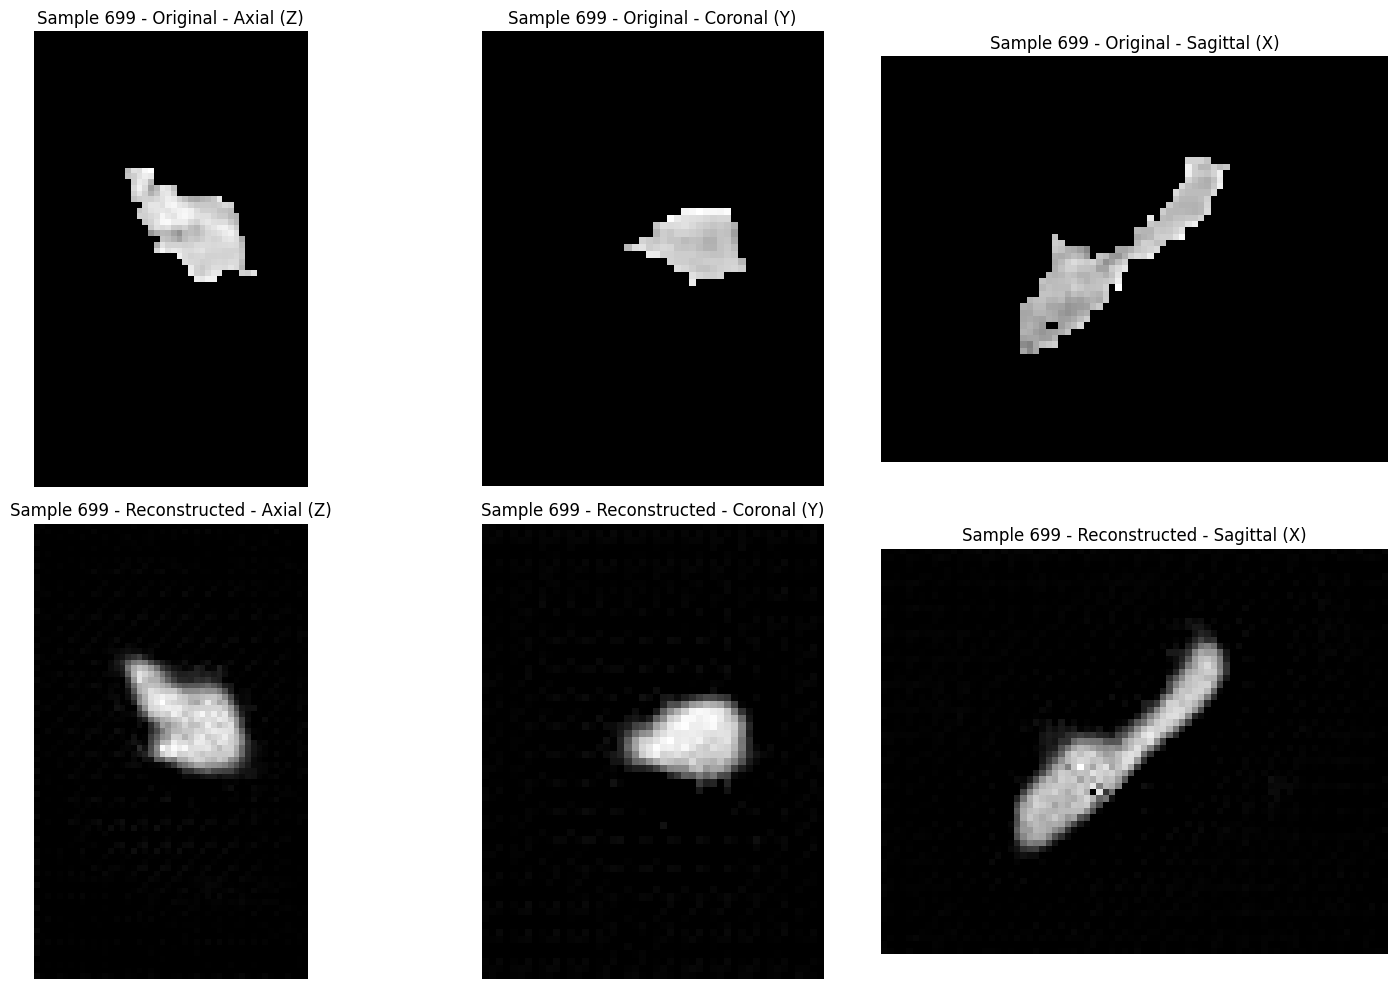

In [11]:
from utils.visualization import visualize_autoencoder_reconstruction

sample_1 = dataset[699]
visualize_autoencoder_reconstruction(autoencoder, sample_1, device, substructure_index=0, title_prefix="Sample 699 - ")

In [12]:
subc_str = 'Hippocampus (lh)'
dataset_feats.query(f"subc_str == '{subc_str}'")

,subject_id,record_id,subc_str,label,age,features
0,OAS30647,OAS30647_MR_d0232,Hippocampus (lh),0.0,55.165615,"[2.7699037, 0.95168304, -1.5440829, -0.4444337..."
10,OAS31405,OAS31405_MR_d0149,Hippocampus (lh),0.0,56.018219,"[3.022387, -0.6704088, -1.6076809, -0.3770126,..."
20,OAS30901,OAS30901_MR_d0155,Hippocampus (lh),1.0,65.804657,"[3.5981214, -0.8740107, -2.1794276, 0.21547209..."
30,OAS30534,OAS30534_MR_d3728,Hippocampus (lh),0.0,76.703697,"[3.7283182, 0.49735078, -2.0950744, 0.08804624..."
40,OAS30120,OAS30120_MR_d0784,Hippocampus (lh),1.0,85.837944,"[4.2672715, -1.623444, -2.7194083, 0.6901709, ..."
...,...,...,...,...,...,...
26740,OAS31031,OAS31031_MR_d0069,Hippocampus (lh),0.0,60.419041,"[3.728439, -0.25535586, -1.8171554, 0.10417895..."
26750,OAS30818,OAS30818_MR_d1720,Hippocampus (lh),0.0,74.772331,"[3.689301, 0.37090033, -2.1468854, -0.0383632,..."
26760,OAS30235,OAS30235_MR_d1175,Hippocampus (lh),0.0,60.679176,"[3.8938575, 0.5759143, -1.4848479, 0.024616707..."
26770,OAS30846,OAS30846_MR_d0160,Hippocampus (lh),0.0,59.018356,"[2.7334723, 0.3066973, -0.9157775, -0.82261956..."


In [13]:
np.stack(dataset_feats['subc_str'].values)

array(['Hippocampus (lh)', 'Hippocampus (rh)', 'Amygdala (lh)', ...,
       'Caudate (rh)', 'Putamen (lh)', 'Putamen (rh)'],
      shape=(26790,), dtype='<U16')

## Embedding 2d representation

/home/maia-user/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/maia-user/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


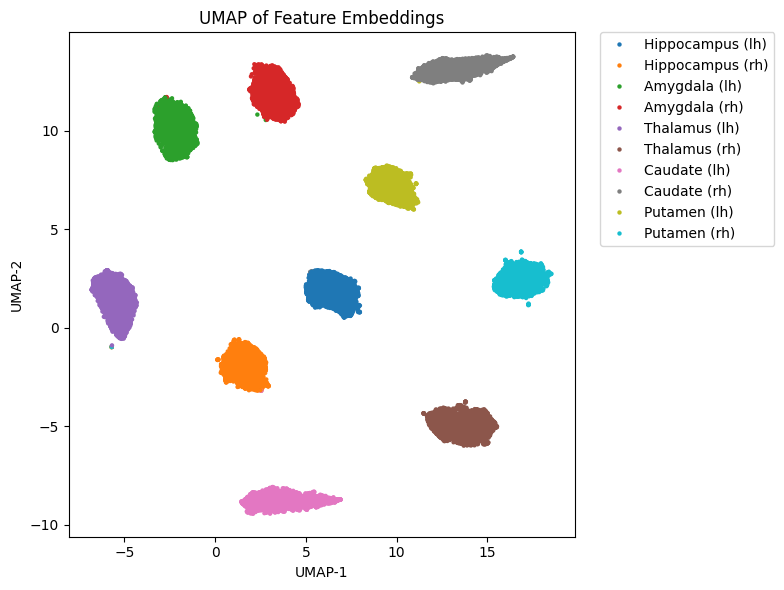

In [14]:
from cbir.projection import compute_umap_embeddings, plot_projection

# Let's say you have a feature matrix and optional labels
features = np.stack(dataset_feats['features'].values)
labels = np.stack(dataset_feats['subc_str'].values)

embedding = compute_umap_embeddings(features)
plot_projection(embedding, labels=labels, title="UMAP of Feature Embeddings")


In [15]:
dataset_feats.columns

Index(['subject_id', 'record_id', 'subc_str', 'label', 'age', 'features'], dtype='object')

In [16]:
dataset_feats['subc_str'].unique()

array(['Hippocampus (lh)', 'Hippocampus (rh)', 'Amygdala (lh)',
       'Amygdala (rh)', 'Thalamus (lh)', 'Thalamus (rh)', 'Caudate (lh)',
       'Caudate (rh)', 'Putamen (lh)', 'Putamen (rh)'], dtype=object)

/home/maia-user/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/maia-user/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


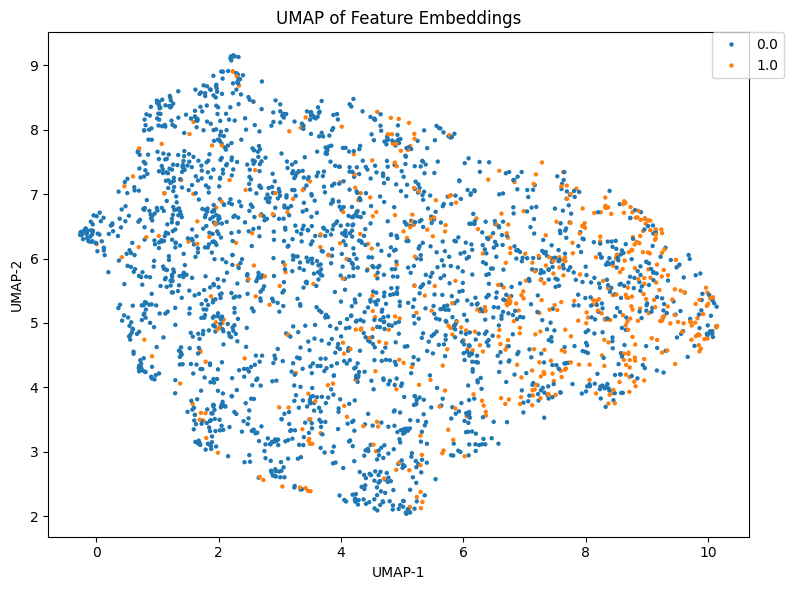

In [17]:
from cbir.projection import compute_umap_embeddings, plot_projection

# Let's say you have a feature matrix and optional labels
subc_str = 'Thalamus (lh)'
features = np.stack(dataset_feats.query(f"subc_str == '{subc_str}'")['features'].values)
labels = np.stack(dataset_feats.query(f"subc_str == '{subc_str}'")['label'].values)

embedding = compute_umap_embeddings(features)
plot_projection(embedding, labels=labels, title="UMAP of Feature Embeddings")

## Intra-subject evaluation

In [18]:
from cbir.feature_engineering import prepare_dataset_with_combined_features
from cbir.evaluation import evaluate_similarity_retrieval

# Example usage
subc_strs = ['Amygdala (lh)', 'Hippocampus (lh)']
top_k = 1

combined_dataset = prepare_dataset_with_combined_features(dataset_feats, subc_strs)
metrics = evaluate_similarity_retrieval(combined_dataset, top_k, class_column="subject_id")

print(f"Precision@{top_k}: {metrics['precision@k']:.4f}")
print(f"Success@{top_k}: {metrics['success@k']:.4f}")

Precision@1: 0.6611
Success@1: 0.6611


In [19]:
evaluate_similarity_retrieval(combined_dataset, top_k, class_column="subject_id")

{'precision@k': np.float64(0.6610675625233297),
 'success@k': 0.6610675625233297,
 'num_evaluated': 2679}

In [20]:
from tabulate import tabulate
from tqdm import tqdm
import pandas as pd
from cbir.feature_engineering import prepare_dataset_with_combined_features
from cbir.evaluation import evaluate_similarity_retrieval

results = []
list_subc_strs = [
    ['Hippocampus (lh)'],
    ['Hippocampus (rh)'],
    ['Amygdala (lh)'],
    ['Amygdala (rh)'],
    ['Thalamus (lh)'],
    ['Thalamus (rh)'],
    ['Caudate (lh)'],
    ['Caudate (rh)'],
    ['Putamen (lh)'],
    ['Putamen (rh)'],
    ['Hippocampus (lh)', 'Hippocampus (rh)'],
    ['Amygdala (lh)', 'Amygdala (rh)'],
    ['Thalamus (lh)', 'Thalamus (rh)'],
    ['Caudate (lh)', 'Caudate (rh)'],
    ['Putamen (lh)', 'Putamen (rh)'],
    list(dataset_feats['subc_str'].unique()),
]

list_top_k = [1, 3, 5]

# Estimate total iterations
total_iterations = len(list_subc_strs) * len(list_top_k)

with tqdm(total=total_iterations, desc="Evaluating combinations") as pbar:
    for subc_strs in list_subc_strs:
        for top_k in list_top_k:
            combined_dataset = prepare_dataset_with_combined_features(dataset_feats, subc_strs)
            metrics = evaluate_similarity_retrieval(combined_dataset, top_k, class_column="subject_id")

            results.append({
                "Structures": ', '.join(subc_strs),
                "Top-K": top_k,
                "Precision@K": round(metrics['precision@k'], 4),
                "Success@K": round(metrics['success@k'], 4),
                "Evaluated Records": metrics['num_evaluated'],
            })

            pbar.update(1)  # Increment progress

# Pretty print results
print(tabulate(results, headers="keys", tablefmt="fancy_grid"))
    

Evaluating combinations: 100%|██████████| 48/48 [06:45<00:00,  8.45s/it]

╒════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╤═════════╤═══════════════╤═════════════╤═════════════════════╕
│ Structures                                                                                                                                             │   Top-K │   Precision@K │   Success@K │   Evaluated Records │
╞════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╪═════════╪═══════════════╪═════════════╪═════════════════════╡
│ Hippocampus (lh)                                                                                                                                       │       1 │        0.6644 │      0.6644 │                2679 │
├───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

In [21]:
pd.DataFrame(results)

,Structures,Top-K,Precision@K,Success@K,Evaluated Records
0,Hippocampus (lh),1,0.6644,0.6644,2679
1,Hippocampus (lh),3,0.7461,0.9552,1405
2,Hippocampus (lh),5,0.7427,0.9785,558
3,Hippocampus (rh),1,0.6846,0.6846,2679
4,Hippocampus (rh),3,0.7601,0.9616,1405
5,Hippocampus (rh),5,0.7609,0.9785,558
6,Amygdala (lh),1,0.3968,0.3968,2679
7,Amygdala (lh),3,0.4057,0.7110,1405
8,Amygdala (lh),5,0.4047,0.8369,558
9,Amygdala (rh),1,0.3897,0.3897,2679


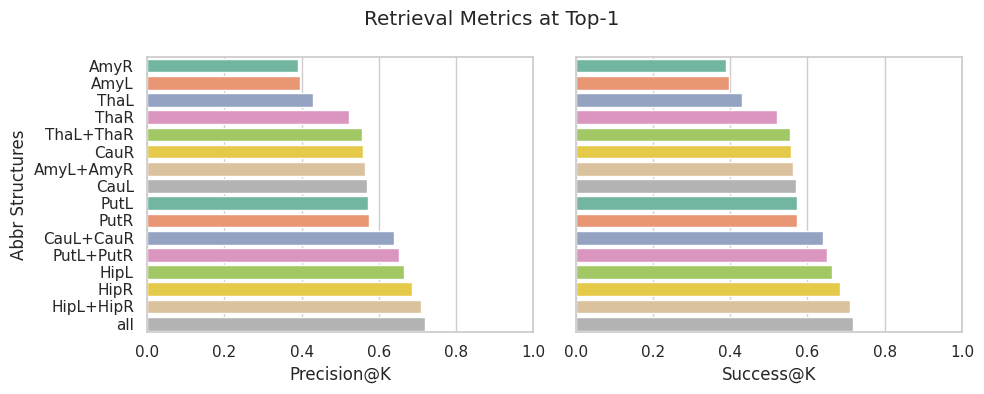

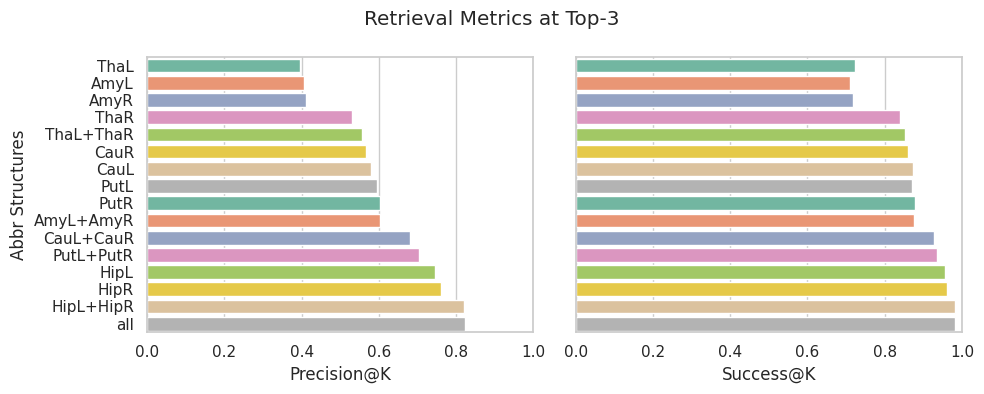

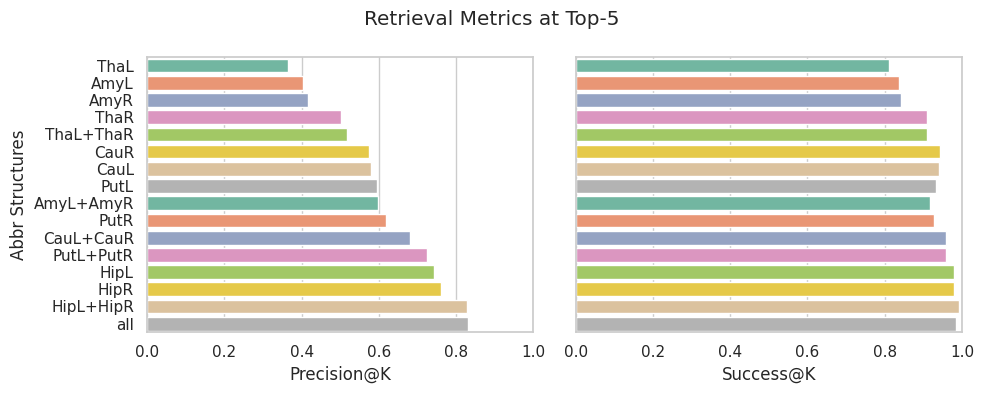

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style and font size for clarity
plt.style.use('default')
plt.rcParams.update({'font.size': 7})

# Abbreviations
structure_abbr = {
    'Hippocampus (lh)': 'HipL',
    'Hippocampus (rh)': 'HipR',
    'Amygdala (lh)': 'AmyL',
    'Amygdala (rh)': 'AmyR',
    'Thalamus (lh)': 'ThaL',
    'Thalamus (rh)': 'ThaR',
    'Caudate (lh)': 'CauL',
    'Caudate (rh)': 'CauR',
    'Putamen (lh)': 'PutL',
    'Putamen (rh)': 'PutR',
}

def abbreviate_structures(structure_str):
    if len(structure_str.split(', ')) >= 10:
        return 'all'
    return '+'.join([structure_abbr.get(s.strip(), s) for s in structure_str.split(', ')])

df = pd.DataFrame(results)
df['Abbr Structures'] = df['Structures'].apply(abbreviate_structures)

# Plotting
sns.set(style="whitegrid")
unique_k = sorted(df['Top-K'].unique())

for k in unique_k:
    df_k = df[df['Top-K'] == k].sort_values(by='Precision@K', ascending=True)

    fig, axes = plt.subplots(1, 2, figsize=(10, max(4, 0.2 * len(df_k))), sharey=True)

    for i, metric in enumerate(['Precision@K', 'Success@K']):
        sns.barplot(
                    data=df_k,
                    y='Abbr Structures',
                    x=metric,
                    ax=axes[i],
                    hue='Abbr Structures',
                    dodge=False,
                    legend=False,
                    palette='Set2'
                )
        axes[i].set_xlim([0, 1])


    plt.suptitle(f'Retrieval Metrics at Top-{k}')
    plt.tight_layout()
    plt.show()




## Evaluation class-level

In [24]:
from cbir.feature_engineering import prepare_dataset_with_combined_features
from cbir.evaluation import evaluate_similarity_retrieval

# Example usage
subc_strs = ['Amygdala (lh)', 'Hippocampus (lh)']
top_k = 3

combined_dataset = prepare_dataset_with_combined_features(dataset_feats, subc_strs)
metrics = evaluate_similarity_retrieval(combined_dataset, top_k, class_column="label")

print(f"Precision@{top_k}: {metrics['precision@k']:.4f}")
print(f"Success@{top_k}: {metrics['success@k']:.4f}")

Precision@3: 0.8233
Success@3: 0.9518


In [25]:
from tabulate import tabulate
from tqdm import tqdm
import pandas as pd
from cbir.feature_engineering import prepare_dataset_with_combined_features
from cbir.evaluation import evaluate_similarity_retrieval

results = []
list_subc_strs = [
    ['Hippocampus (lh)'],
    ['Hippocampus (rh)'],
    ['Amygdala (lh)'],
    ['Amygdala (rh)'],
    ['Thalamus (lh)'],
    ['Thalamus (rh)'],
    ['Caudate (lh)'],
    ['Caudate (rh)'],
    ['Putamen (lh)'],
    ['Putamen (rh)'],
    ['Hippocampus (lh)', 'Hippocampus (rh)'],
    ['Amygdala (lh)', 'Amygdala (rh)'],
    ['Thalamus (lh)', 'Thalamus (rh)'],
    ['Caudate (lh)', 'Caudate (rh)'],
    ['Putamen (lh)', 'Putamen (rh)'],
    list(dataset_feats['subc_str'].unique()),
]

list_top_k = [1, 3, 5]

# Estimate total iterations
total_iterations = len(list_subc_strs) * len(list_top_k)

with tqdm(total=total_iterations, desc="Evaluating combinations") as pbar:
    for subc_strs in list_subc_strs:
        for top_k in list_top_k:
            combined_dataset = prepare_dataset_with_combined_features(dataset_feats, subc_strs)
            metrics = evaluate_similarity_retrieval(combined_dataset, top_k, class_column="label")

            results.append({
                "Structures": ', '.join(subc_strs),
                "Top-K": top_k,
                "Precision@K": round(metrics['precision@k'], 4),
                "Success@K": round(metrics['success@k'], 4),
                "Evaluated Records": metrics['num_evaluated'],
            })

            pbar.update(1)  # Increment progress

# Pretty print results
print(tabulate(results, headers="keys", tablefmt="fancy_grid"))
    

Evaluating combinations: 100%|██████████| 48/48 [09:37<00:00, 12.02s/it]

╒════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╤═════════╤═══════════════╤═════════════╤═════════════════════╕
│ Structures                                                                                                                                             │   Top-K │   Precision@K │   Success@K │   Evaluated Records │
╞════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╪═════════╪═══════════════╪═════════════╪═════════════════════╡
│ Hippocampus (lh)                                                                                                                                       │       1 │        0.8611 │      0.8611 │                2679 │
├───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

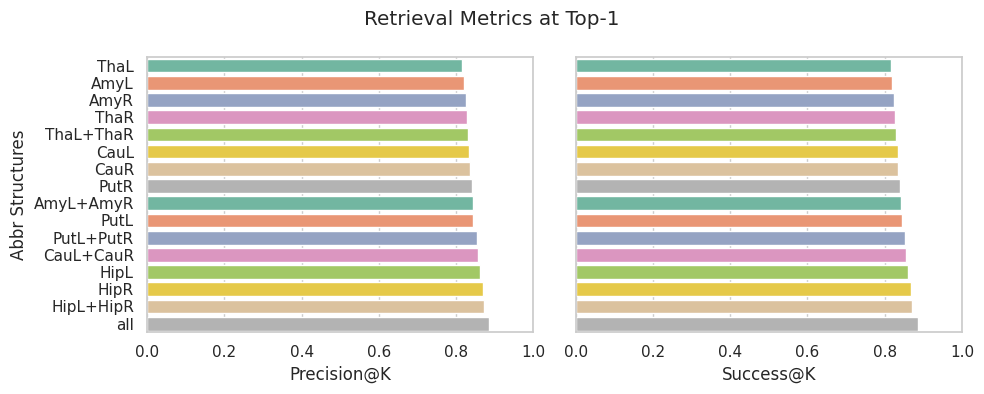

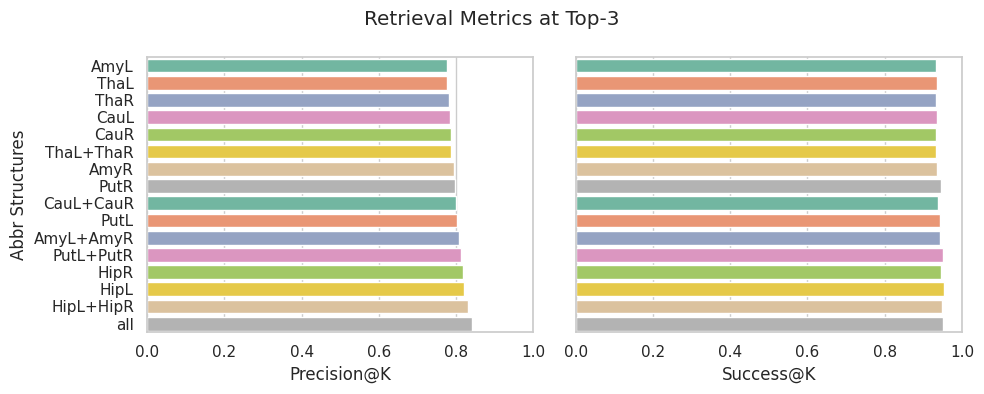

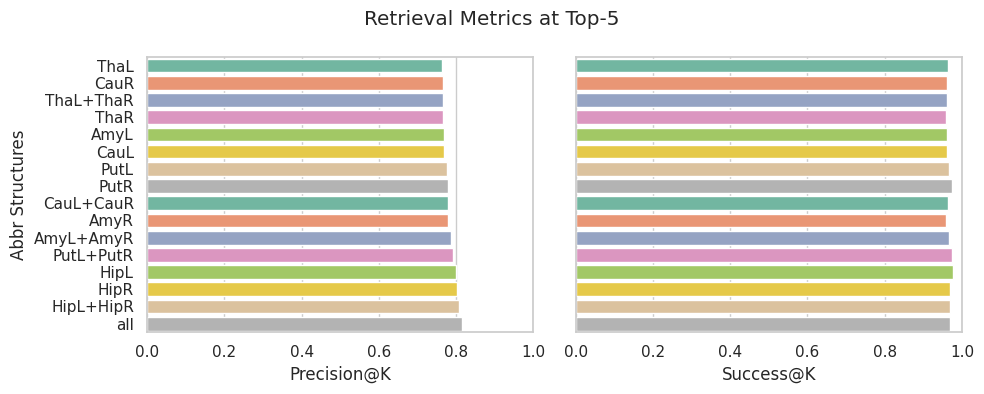

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style and font size for clarity
plt.style.use('default')
plt.rcParams.update({'font.size': 7})

# Abbreviations
structure_abbr = {
    'Hippocampus (lh)': 'HipL',
    'Hippocampus (rh)': 'HipR',
    'Amygdala (lh)': 'AmyL',
    'Amygdala (rh)': 'AmyR',
    'Thalamus (lh)': 'ThaL',
    'Thalamus (rh)': 'ThaR',
    'Caudate (lh)': 'CauL',
    'Caudate (rh)': 'CauR',
    'Putamen (lh)': 'PutL',
    'Putamen (rh)': 'PutR',
}

def abbreviate_structures(structure_str):
    if len(structure_str.split(', ')) >= 10:
        return 'all'
    return '+'.join([structure_abbr.get(s.strip(), s) for s in structure_str.split(', ')])

df = pd.DataFrame(results)
df['Abbr Structures'] = df['Structures'].apply(abbreviate_structures)

# Plotting
sns.set(style="whitegrid")
unique_k = sorted(df['Top-K'].unique())

for k in unique_k:
    df_k = df[df['Top-K'] == k].sort_values(by='Precision@K', ascending=True)

    fig, axes = plt.subplots(1, 2, figsize=(10, max(4, 0.2 * len(df_k))), sharey=True)

    for i, metric in enumerate(['Precision@K', 'Success@K']):
        sns.barplot(
                    data=df_k,
                    y='Abbr Structures',
                    x=metric,
                    ax=axes[i],
                    hue='Abbr Structures',
                    dodge=False,
                    legend=False,
                    palette='Set2'
                )
        axes[i].set_xlim([0, 1])


    plt.suptitle(f'Retrieval Metrics at Top-{k}')
    plt.tight_layout()
    plt.show()
